In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import streamlit as st
import holidays

In [40]:
ventas_path = "../data/raw/entrenamiento/ventas.csv"
competencia_path = "../data/raw/entrenamiento/competencia.csv"

ventas_df = pd.read_csv(ventas_path)
competencia_df = pd.read_csv(competencia_path)


print("Ventas:")
print(ventas_df.head())
print("\nCompetencia:")
print(competencia_df.head())



Ventas:
        fecha producto_id                            nombre categoria  \
0  2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1  2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2  2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3  2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4  2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  
0        118.36    710.16  
1        136.82   1368.20  
2         84.93    169.86  
3         75.42    1

In [42]:
# Copia de seguridad
df = ventas_df.copy()

print("===== INFORME DE CALIDAD DE DATOS =====\n")

# 1. Tipos de datos
print("🔹 TIPOS DE DATOS:")
print(df.dtypes)
print("\n")

# 2. Valores nulos
print("🔹 VALORES NULOS:")
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100
df_nulos = pd.DataFrame({
    'nulos': nulos,
    'porcentaje_%': porcentaje_nulos
})
print(df_nulos)
print("\n")

# 3. Duplicados
duplicados = df.duplicated().sum()
print("🔹 DUPLICADOS:")
print(f"Cantidad de filas duplicadas: {duplicados}")
print("\n")

# 4. Descriptivos numéricos
print("🔹 ESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS):")
print(df.describe())
print("\n")

# 5. Descriptivos categóricos
print("🔹 ESTADÍSTICAS DE VARIABLES CATEGÓRICAS:")
print(df.describe(include='object'))
print("\n")

# 6. Valores únicos por columna
print("🔹 VALORES ÚNICOS POR COLUMNA:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")
print("\n")

# 7. Validación de columnas clave
print("🔹 VALIDACIÓN DE COLUMNAS CLAVE:")

print("Fechas únicas:", df['fecha'].nunique())
print("Productos únicos:", df['producto_id'].nunique())

print("\n===== FIN DEL INFORME =====")

===== INFORME DE CALIDAD DE DATOS =====

🔹 TIPOS DE DATOS:
fecha                    str
producto_id              str
nombre                   str
categoria                str
subcategoria             str
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object


🔹 VALORES NULOS:
                   nulos  porcentaje_%
fecha                  0           0.0
producto_id            0           0.0
nombre                 0           0.0
categoria              0           0.0
subcategoria           0           0.0
precio_base            0           0.0
es_estrella            0           0.0
unidades_vendidas      0           0.0
precio_venta           0           0.0
ingresos               0           0.0


🔹 DUPLICADOS:
Cantidad de filas duplicadas: 0


🔹 ESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS):
       precio_base  unidades_vendidas  precio_venta      ingresos
count  3552.000000         3552.

C:\Users\ojgue\AppData\Local\Temp\ipykernel_73740\3657267204.py:35: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'))


In [43]:
# Copia de seguridad
df = competencia_df.copy()

print("===== INFORME DE CALIDAD DE DATOS =====\n")

# 1. Tipos de datos
print("🔹 TIPOS DE DATOS:")
print(df.dtypes)
print("\n")

# 2. Valores nulos
print("🔹 VALORES NULOS:")
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100
df_nulos = pd.DataFrame({
    'nulos': nulos,
    'porcentaje_%': porcentaje_nulos
})
print(df_nulos)
print("\n")

# 3. Duplicados
duplicados = df.duplicated().sum()
print("🔹 DUPLICADOS:")
print(f"Cantidad de filas duplicadas: {duplicados}")
print("\n")

# 4. Descriptivos numéricos
print("🔹 ESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS):")
print(df.describe())
print("\n")

# 5. Descriptivos categóricos
print("🔹 ESTADÍSTICAS DE VARIABLES CATEGÓRICAS:")
print(df.describe(include='object'))
print("\n")

# 6. Valores únicos por columna
print("🔹 VALORES ÚNICOS POR COLUMNA:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")
print("\n")

# 7. Validación de columnas clave
print("🔹 VALIDACIÓN DE COLUMNAS CLAVE:")

print("Fechas únicas:", df['fecha'].nunique())
print("Productos únicos:", df['producto_id'].nunique())

print("\n===== FIN DEL INFORME =====")

===== INFORME DE CALIDAD DE DATOS =====

🔹 TIPOS DE DATOS:
fecha               str
producto_id         str
Amazon          float64
Decathlon       float64
Deporvillage    float64
dtype: object


🔹 VALORES NULOS:
              nulos  porcentaje_%
fecha             0           0.0
producto_id       0           0.0
Amazon            0           0.0
Decathlon         0           0.0
Deporvillage      0           0.0


🔹 DUPLICADOS:
Cantidad de filas duplicadas: 0


🔹 ESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS):
            Amazon    Decathlon  Deporvillage
count  3552.000000  3552.000000   3552.000000
mean    118.623407   111.412182    118.894628
std     156.095628   148.508132    160.216448
min      16.850000    15.450000     16.770000
25%      47.117500    43.285000     47.310000
50%      73.180000    66.285000     72.700000
75%     114.342500   111.172500    114.985000
max     858.350000   867.337500    932.325000


🔹 ESTADÍSTICAS DE VARIABLES CATEGÓRICAS:
             fecha producto_id
count

C:\Users\ojgue\AppData\Local\Temp\ipykernel_73740\2952582221.py:35: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'))


In [44]:
ventas_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              3552 non-null   str    
 1   producto_id        3552 non-null   str    
 2   nombre             3552 non-null   str    
 3   categoria          3552 non-null   str    
 4   subcategoria       3552 non-null   str    
 5   precio_base        3552 non-null   int64  
 6   es_estrella        3552 non-null   bool   
 7   unidades_vendidas  3552 non-null   int64  
 8   precio_venta       3552 non-null   float64
 9   ingresos           3552 non-null   float64
dtypes: bool(1), float64(2), int64(2), str(5)
memory usage: 467.8 KB


In [45]:
competencia_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fecha         3552 non-null   str    
 1   producto_id   3552 non-null   str    
 2   Amazon        3552 non-null   float64
 3   Decathlon     3552 non-null   float64
 4   Deporvillage  3552 non-null   float64
dtypes: float64(3), str(2)
memory usage: 201.3 KB


In [46]:
df = pd.merge(
    ventas_df,
    competencia_df,
    how='inner',
    on=['fecha', 'producto_id']
)


print(df.head())

        fecha producto_id                            nombre categoria  \
0  2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1  2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2  2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3  2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4  2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  Amazon  Decathlon  Deporvillage  
0        118.36    710.16   82.96     111.88         97.43  
1        136.82   

In [47]:
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Copia
df = df.copy()

# Convertir fecha
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')

# Crear variables útiles
df['anio'] = df['fecha'].dt.year
df['dia_semana'] = df['fecha'].dt.day_name()

print(df.head())

       fecha producto_id                            nombre categoria  \
0 2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1 2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2 2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3 2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4 2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  Amazon  Decathlon  Deporvillage  anio dia_semana  
0        118.36    710.16   82.96     111.88         97.43  2021    

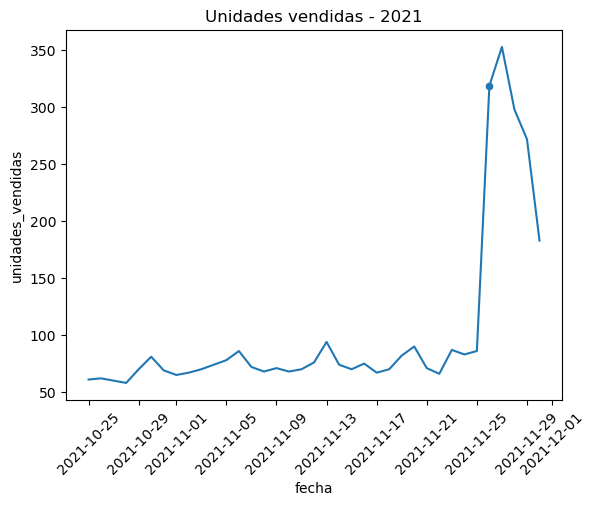

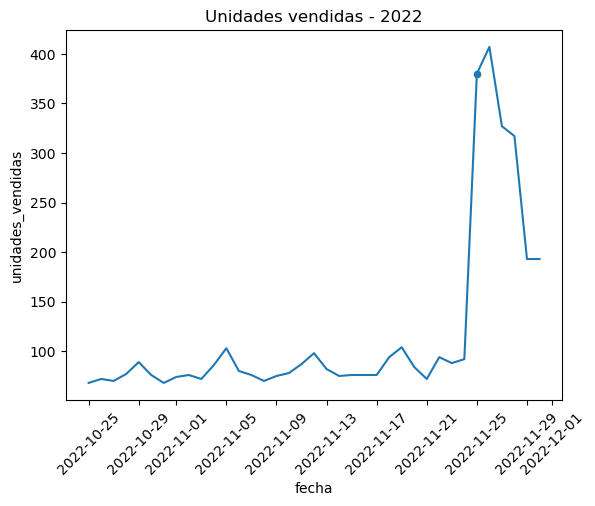

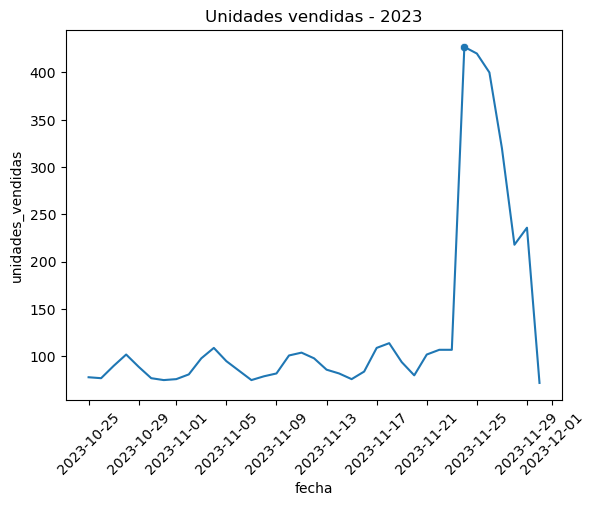

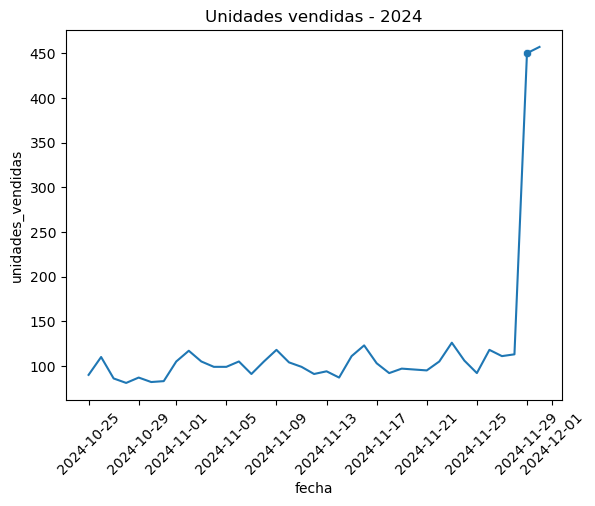

In [49]:
import holidays

# República Dominicana
do_holidays = holidays.DominicanRepublic()

# Black Friday (aproximación: último viernes de noviembre)
df['es_black_friday'] = (
    (df['fecha'].dt.month == 11) &
    (df['fecha'].dt.weekday == 4) &
    (df['fecha'].dt.day >= 23)
)

# Agrupar
ts = df.groupby(['fecha', 'anio'])['unidades_vendidas'].sum().reset_index()

# Graficar por año
for year in ts['anio'].unique():
    data_year = ts[ts['anio'] == year]

    plt.figure()
    sns.lineplot(data=data_year, x='fecha', y='unidades_vendidas')

    # Marcar Black Friday
    bf = df[(df['anio'] == year) & (df['es_black_friday'])]
    bf_group = bf.groupby('fecha')['unidades_vendidas'].sum().reset_index()

    sns.scatterplot(data=bf_group, x='fecha', y='unidades_vendidas')

    plt.title(f"Unidades vendidas - {year}")
    plt.xticks(rotation=45)
    plt.show()

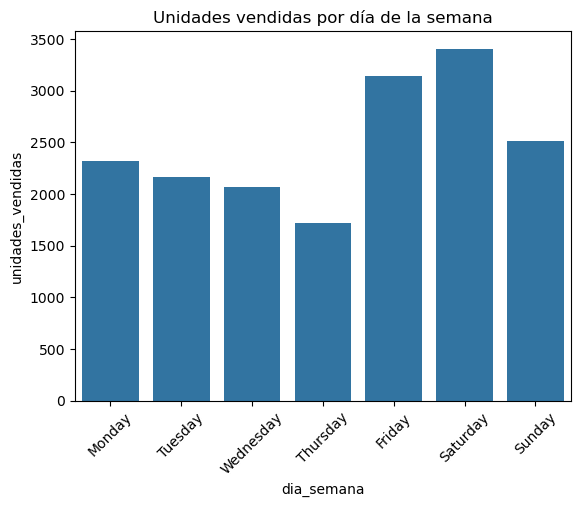

In [50]:
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df_dia = df.groupby('dia_semana')['unidades_vendidas'].sum().reindex(orden_dias).reset_index()

plt.figure()
sns.barplot(data=df_dia, x='dia_semana', y='unidades_vendidas')
plt.title("Unidades vendidas por día de la semana")
plt.xticks(rotation=45)
plt.show()

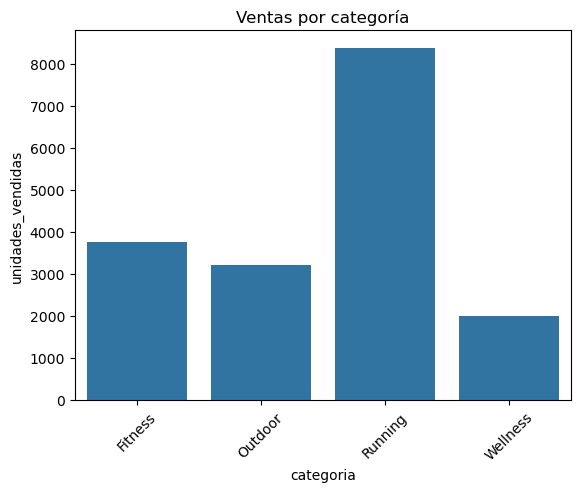

In [51]:
df_cat = df.groupby('categoria')['unidades_vendidas'].sum().reset_index()

plt.figure()
sns.barplot(data=df_cat, x='categoria', y='unidades_vendidas')
plt.title("Ventas por categoría")
plt.xticks(rotation=45)
plt.show()

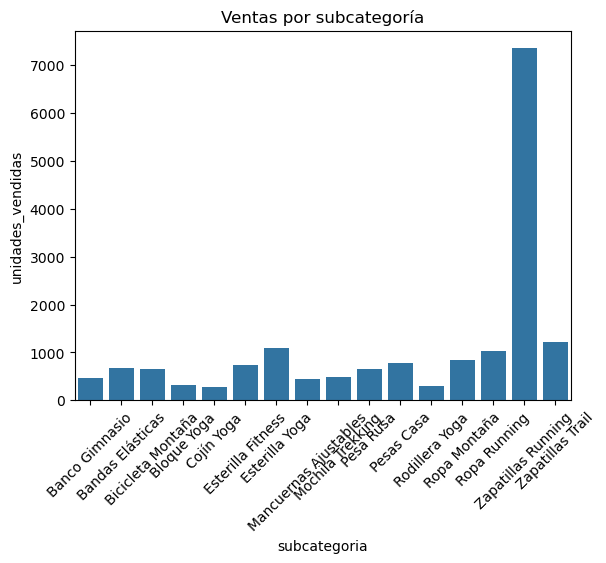

In [52]:
df_subcat = df.groupby('subcategoria')['unidades_vendidas'].sum().reset_index()

plt.figure()
sns.barplot(data=df_subcat, x='subcategoria', y='unidades_vendidas')
plt.title("Ventas por subcategoría")
plt.xticks(rotation=45)
plt.show()

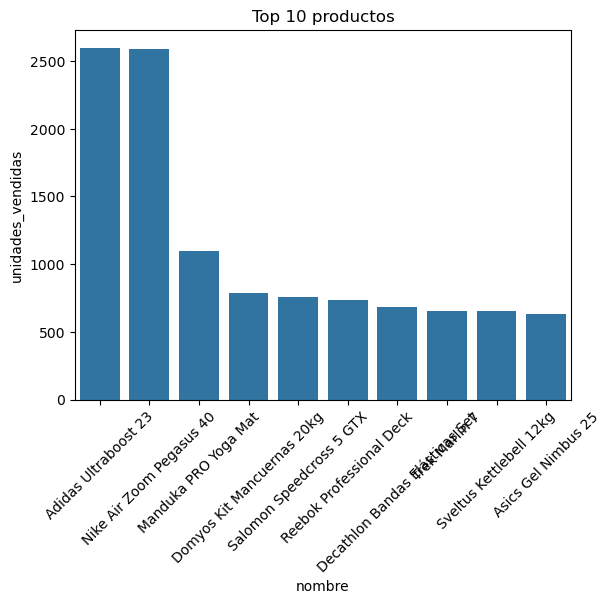

In [53]:
top_productos = df.groupby('nombre')['unidades_vendidas'].sum().reset_index()
top_productos = top_productos.sort_values(by='unidades_vendidas', ascending=False).head(10)

plt.figure()
sns.barplot(data=top_productos, x='nombre', y='unidades_vendidas')
plt.title("Top 10 productos")
plt.xticks(rotation=45)
plt.show()

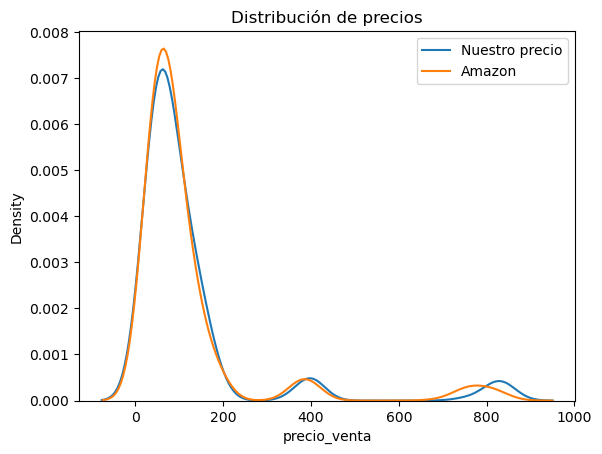

In [54]:
plt.figure()

sns.kdeplot(data=df, x='precio_venta', label='Nuestro precio')
sns.kdeplot(data=df, x='Amazon', label='Amazon')

plt.title("Distribución de precios")
plt.legend()
plt.show()

In [55]:
# Asegurar que 'fecha' sea datetime
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')

In [56]:
df['anio'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['nombre_dia'] = df['fecha'].dt.day_name()
df['semana_anio'] = df['fecha'].dt.isocalendar().week
df['trimestre'] = df['fecha'].dt.quarter

In [57]:
df['es_fin_semana'] = df['dia_semana'].isin([5, 6]).astype(int)

In [58]:
import holidays

rd_holidays = holidays.DominicanRepublic()

df['es_festivo'] = df['fecha'].isin(rd_holidays).astype(int)

In [59]:
# Función para Black Friday (último viernes de noviembre)
def es_black_friday(fecha):
    if fecha.month == 11 and fecha.weekday() == 4:
        ultimo_dia = pd.Timestamp(year=fecha.year, month=11, day=30)
        ultimo_viernes = ultimo_dia - pd.Timedelta(days=(ultimo_dia.weekday() - 4) % 7)
        return fecha == ultimo_viernes
    return False

# Función para Cyber Monday (lunes después de Black Friday)
def es_cyber_monday(fecha):
    if fecha.month == 11 and fecha.weekday() == 0:
        return es_black_friday(fecha - pd.Timedelta(days=3))
    return False

df['es_black_friday'] = df['fecha'].apply(es_black_friday).astype(int)
df['es_cyber_monday'] = df['fecha'].apply(es_cyber_monday).astype(int)

In [60]:
# Inicio / fin de mes
df['inicio_mes'] = df['fecha'].dt.is_month_start.astype(int)
df['fin_mes'] = df['fecha'].dt.is_month_end.astype(int)

# Inicio / fin de trimestre
df['inicio_trimestre'] = df['fecha'].dt.is_quarter_start.astype(int)
df['fin_trimestre'] = df['fecha'].dt.is_quarter_end.astype(int)

# Día del año (estacionalidad)
df['dia_anio'] = df['fecha'].dt.dayofyear

# Semana del mes (aproximada)
df['semana_mes'] = ((df['dia'] - 1) // 7 + 1)

In [61]:
df[['fecha', 'anio', 'mes', 'dia_semana', 'es_fin_semana', 
    'es_festivo', 'es_black_friday', 'es_cyber_monday']].head()

,fecha,anio,mes,dia_semana,es_fin_semana,es_festivo,es_black_friday,es_cyber_monday
0,2021-10-25,2021,10,0,0,0,0,0
1,2021-10-25,2021,10,0,0,0,0,0
2,2021-10-25,2021,10,0,0,0,0,0
3,2021-10-25,2021,10,0,0,0,0,0
4,2021-10-25,2021,10,0,0,0,0,0


In [62]:
# Ordenar por producto y fecha (fundamental para lags correctos)
df = df.sort_values(by=['producto_id', 'fecha'])

In [63]:
# Crear lags del 1 al 7 por producto y año
for lag in range(1, 8):
    df[f'lag_{lag}'] = (
        df.groupby(['producto_id', 'anio'])['unidades_vendidas']
        .shift(lag)
    )

In [64]:
df['media_movil_7'] = (
    df.groupby(['producto_id', 'anio'])['unidades_vendidas']
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

In [65]:
# Columnas creadas
columnas_lag = [f'lag_{i}' for i in range(1, 8)] + ['media_movil_7']

# Eliminar filas con nulos en esas columnas
df = df.dropna(subset=columnas_lag)

In [66]:
df.shape

(2880, 38)

In [67]:
df[['fecha', 'producto_id', 'unidades_vendidas',
    'lag_1', 'lag_2', 'lag_3', 'lag_4',
    'lag_5', 'lag_6', 'lag_7',
    'media_movil_7']].head(10)

,fecha,producto_id,unidades_vendidas,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,media_movil_7
168,2021-11-01,PROD_001,7,9.0,12.0,12.0,7.0,8.0,8.0,6.0,8.857143
192,2021-11-02,PROD_001,10,7.0,9.0,12.0,12.0,7.0,8.0,8.0,9.000000
216,2021-11-03,PROD_001,11,10.0,7.0,9.0,12.0,12.0,7.0,8.0,9.285714
240,2021-11-04,PROD_001,12,11.0,10.0,7.0,9.0,12.0,12.0,7.0,9.714286
264,2021-11-05,PROD_001,10,12.0,11.0,10.0,7.0,9.0,12.0,12.0,10.428571
288,2021-11-06,PROD_001,10,10.0,12.0,11.0,10.0,7.0,9.0,12.0,10.142857
312,2021-11-07,PROD_001,10,10.0,10.0,12.0,11.0,10.0,7.0,9.0,9.857143
336,2021-11-08,PROD_001,9,10.0,10.0,10.0,12.0,11.0,10.0,7.0,10.000000
360,2021-11-09,PROD_001,11,9.0,10.0,10.0,10.0,12.0,11.0,10.0,10.285714
384,2021-11-10,PROD_001,10,11.0,9.0,10.0,10.0,10.0,12.0,11.0,10.428571


In [68]:
df.groupby('anio').size()

anio
2021    720
2022    720
2023    720
2024    720
dtype: int64

In [69]:
df['descuento_pct'] = ((df['precio_venta'] - df['precio_base']) / df['precio_base']) * 100

In [70]:
df[['precio_base', 'precio_venta', 'descuento_pct']].head()

,precio_base,precio_venta,descuento_pct
168,115,115.07,0.060870
192,115,116.10,0.956522
216,115,114.58,-0.365217
240,115,112.23,-2.408696
264,115,113.81,-1.034783


In [71]:
df['descuento_pct'] = np.where(
    df['precio_base'] != 0,
    ((df['precio_venta'] - df['precio_base']) / df['precio_base']) * 100,
    np.nan
)

In [72]:
print(dir())


['In', 'Out', '_', '_22', '_27', '_28', '_29', '_31', '_47', '_61', '_66', '_67', '_68', '_70', '_8', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i3', '_i30', '_i31', '_i32', '_i33', '_i34', '_i35', '_i36', '_i37', '_i38', '_i39', '_i4', '_i40', '_i41', '_i42', '_i43', '_i44', '_i45', '_i46', '_i47', '_i48', '_i49', '_i5', '_i50', '_i51', '_i52', '_i53', '_i54', '_i55', '_i56', '_i57', '_i58', '_i59', '_i6', '_i60', '_i61', '_i62', '_i63', '_i64', '_i65', '_i66', '_i67', '_i68', '_i69', '_i7', '_i70', '_i71', '_i72', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'bf', 'bf_group', 'col', 'columnas_lag', 'competencia_df', 'competencia_path', 'data_year', 'df', 'df_cat', 'df_dia', 'df_nulos', 'df_subcat', 'do_holidays', '

In [73]:
df['fecha'] = pd.to_datetime(df['fecha']).dt.normalize()
competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha']).dt.normalize()

In [74]:
print(df.columns.to_list())

['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria', 'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta', 'ingresos', 'Amazon', 'Decathlon', 'Deporvillage', 'anio', 'dia_semana', 'es_black_friday', 'mes', 'dia', 'nombre_dia', 'semana_anio', 'trimestre', 'es_fin_semana', 'es_festivo', 'es_cyber_monday', 'inicio_mes', 'fin_mes', 'inicio_trimestre', 'fin_trimestre', 'dia_anio', 'semana_mes', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'media_movil_7', 'descuento_pct']


In [77]:
df = df.merge(
    competencia_df,
    on=['fecha', 'producto_id'],
    how='left'
)

In [78]:
print(df.columns.to_list())

['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria', 'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta', 'ingresos', 'Amazon_x', 'Decathlon_x', 'Deporvillage_x', 'anio', 'dia_semana', 'es_black_friday', 'mes', 'dia', 'nombre_dia', 'semana_anio', 'trimestre', 'es_fin_semana', 'es_festivo', 'es_cyber_monday', 'inicio_mes', 'fin_mes', 'inicio_trimestre', 'fin_trimestre', 'dia_anio', 'semana_mes', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'media_movil_7', 'descuento_pct', 'Amazon_y', 'Decathlon_y', 'Deporvillage_y', 'Amazon', 'Decathlon', 'Deporvillage']


In [79]:
df[['Amazon_x', 'Decathlon_x', 'Deporvillage_x']].head()

,Amazon_x,Decathlon_x,Deporvillage_x
0,81.23,110.51,94.32
1,82.69,107.86,97.91
2,83.83,106.35,95.54
3,81.21,111.61,96.95
4,82.28,109.70,96.53


In [80]:
df[['Amazon', 'Decathlon', 'Deporvillage']].isna().mean()

Amazon          0.0
Decathlon       0.0
Deporvillage    0.0
dtype: float64

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              2880 non-null   datetime64[us]
 1   producto_id        2880 non-null   str           
 2   nombre             2880 non-null   str           
 3   categoria          2880 non-null   str           
 4   subcategoria       2880 non-null   str           
 5   precio_base        2880 non-null   int64         
 6   es_estrella        2880 non-null   bool          
 7   unidades_vendidas  2880 non-null   int64         
 8   precio_venta       2880 non-null   float64       
 9   ingresos           2880 non-null   float64       
 10  Amazon_x           2880 non-null   float64       
 11  Decathlon_x        2880 non-null   float64       
 12  Deporvillage_x     2880 non-null   float64       
 13  anio               2880 non-null   int32         
 14  dia_semana         

In [82]:
df['nombre_h'] = df['nombre']
df['categoria_h'] = df['categoria']
df['subcategoria_h'] = df['subcategoria']

In [83]:
df = pd.get_dummies(
    df,
    columns=['nombre_h', 'categoria_h', 'subcategoria_h'],
    drop_first=False
)

In [84]:
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,115.07,805.49,...,False,False,False,False,False,False,False,False,True,False
1,2021-11-02,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,116.10,1161.00,...,False,False,False,False,False,False,False,False,True,False
2,2021-11-03,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,11,114.58,1260.38,...,False,False,False,False,False,False,False,False,True,False
3,2021-11-04,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,12,112.23,1346.76,...,False,False,False,False,False,False,False,False,True,False
4,2021-11-05,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,113.81,1138.10,...,False,False,False,False,False,False,False,False,True,False


In [85]:
df.to_csv("../data/processed/df_final.csv", index=False)

In [87]:
# Asegurar tipo datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# Crear columna año (si no existe)
df['año'] = df['fecha'].dt.year

# División
train_df = df[(df['año'] >= 2021) & (df['año'] <= 2023)]
validation_df = df[df['año'] == 2024]

# Mostrar cantidad de registros
print("Registros en TRAIN:", len(train_df))
print("Registros en VALIDATION:", len(validation_df))

Registros en TRAIN: 2160
Registros en VALIDATION: 720


In [88]:
print(train_df['fecha'].min(), train_df['fecha'].max())
print(validation_df['fecha'].min(), validation_df['fecha'].max())

2021-11-01 00:00:00 2023-11-30 00:00:00
2024-11-01 00:00:00 2024-11-30 00:00:00


In [90]:
# Variable objetivo
target = 'unidades_vendidas'

# Eliminar variables no válidas
columnas_excluir = ['fecha', 'ingresos']

# Excluir variables tipo objeto
columnas_objeto = train_df.select_dtypes(include=['object']).columns.tolist()

# Features finales
features = [col for col in train_df.columns if col not in columnas_excluir + columnas_objeto + [target]]

C:\Users\ojgue\AppData\Local\Temp\ipykernel_73740\674204764.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_objeto = train_df.select_dtypes(include=['object']).columns.tolist()


In [91]:
from sklearn.ensemble import HistGradientBoostingRegressor

modelo = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_depth=6,
    l2_regularization=1.0,
    random_state=42
)

modelo.fit(train_df[features], train_df[target])

,loss,'squared_error'
,quantile,None
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,6
,min_samples_leaf,20
,l2_regularization,1.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [92]:
pred_train = modelo.predict(train_df[features])
pred_val = modelo.predict(validation_df[features])

In [93]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

mae_train, rmse_train, mape_train = metricas(train_df[target], pred_train)
mae_val, rmse_val, mape_val = metricas(validation_df[target], pred_val)

print("TRAIN -> MAE:", mae_train, "RMSE:", rmse_train, "MAPE:", mape_train)
print("VALID -> MAE:", mae_val, "RMSE:", rmse_val, "MAPE:", mape_val)

TRAIN -> MAE: 0.6075188236043843 RMSE: 1.1500309697849267 MAPE: 14.556948101440808
VALID -> MAE: 1.0532604736550073 RMSE: 2.223802990466813 MAPE: 18.832027943745693


In [94]:
media_train = train_df[target].mean()

pred_naive = np.full(len(validation_df), media_train)

mae_naive, rmse_naive, mape_naive = metricas(validation_df[target], pred_naive)

print("NAIVE -> MAE:", mae_naive, "RMSE:", rmse_naive, "MAPE:", mape_naive)

NAIVE -> MAE: 3.6692888374485593 RMSE: 6.692287781417812 MAPE: 93.02177831978558


In [95]:
print("---- COMPARACIÓN ----")
print("Modelo VALID -> MAE:", mae_val, "RMSE:", rmse_val, "MAPE:", mape_val)
print("Naive  VALID -> MAE:", mae_naive, "RMSE:", rmse_naive, "MAPE:", mape_naive)

---- COMPARACIÓN ----
Modelo VALID -> MAE: 1.0532604736550073 RMSE: 2.223802990466813 MAPE: 18.832027943745693
Naive  VALID -> MAE: 3.6692888374485593 RMSE: 6.692287781417812 MAPE: 93.02177831978558


In [96]:
# Filtrar noviembre 2024
df_nov_2024 = df[
    (df['fecha'].dt.year == 2024) &
    (df['fecha'].dt.month == 11)
]

# Filtrar productos estrella
df_nov_2024 = df_nov_2024[df_nov_2024['es_estrella'] == 1]

In [97]:
# Usar mismas features del modelo
predicciones = modelo.predict(df_nov_2024[features])

df_nov_2024['prediccion'] = predicciones

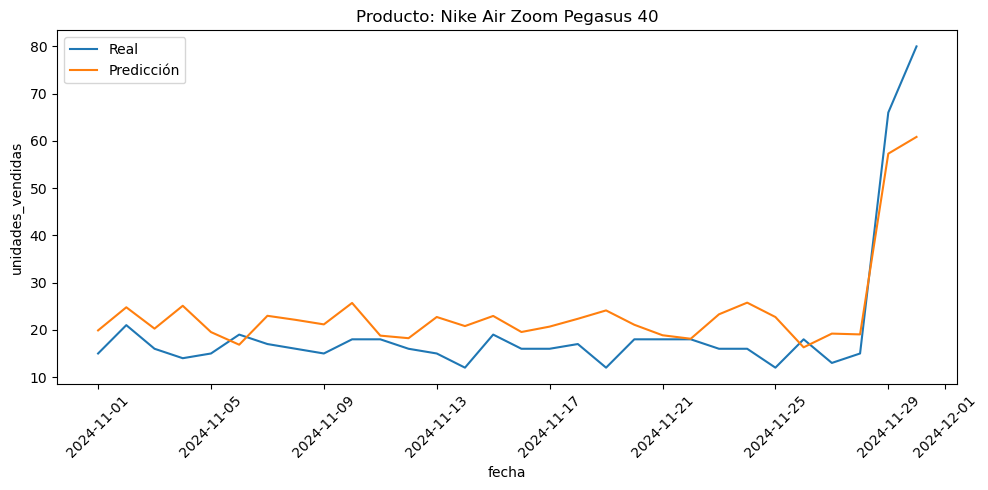

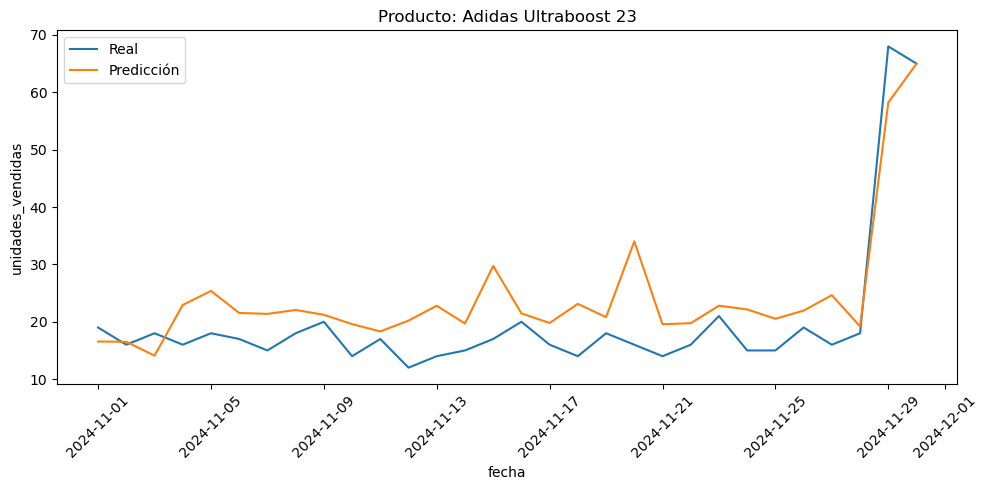

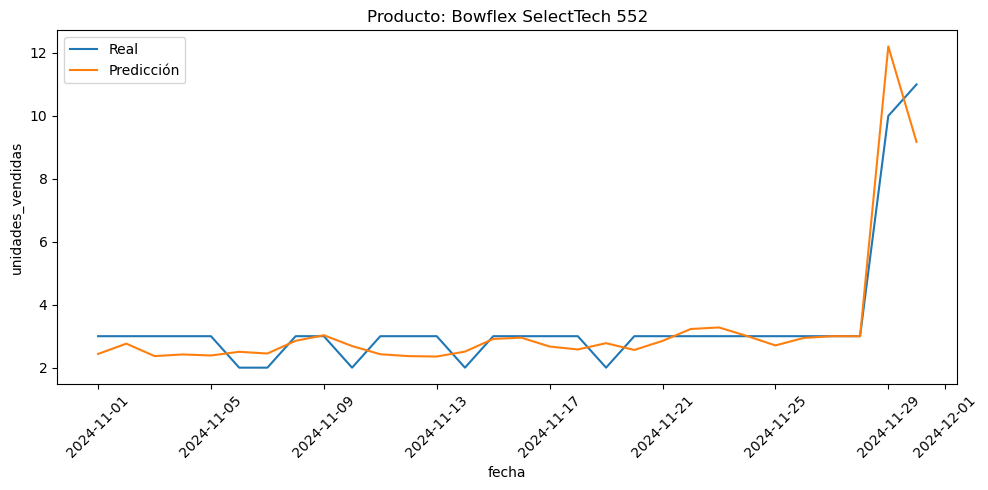

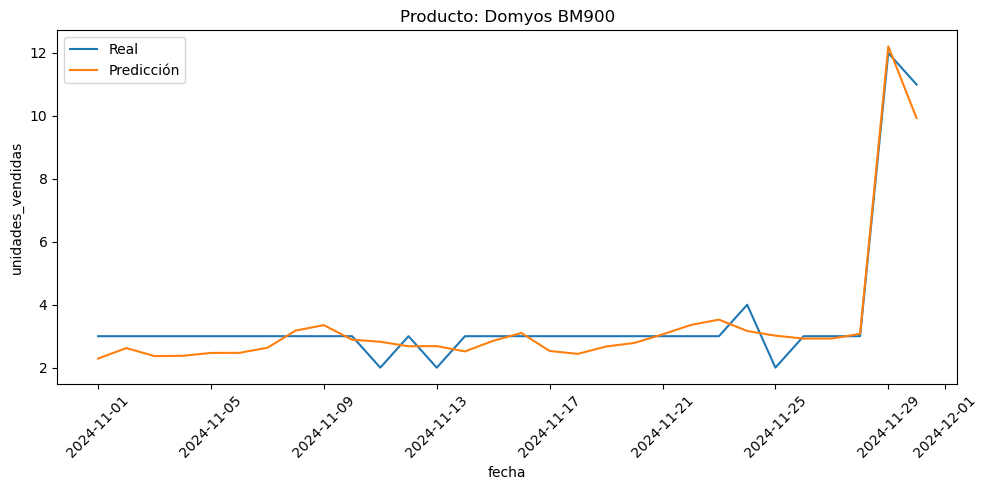

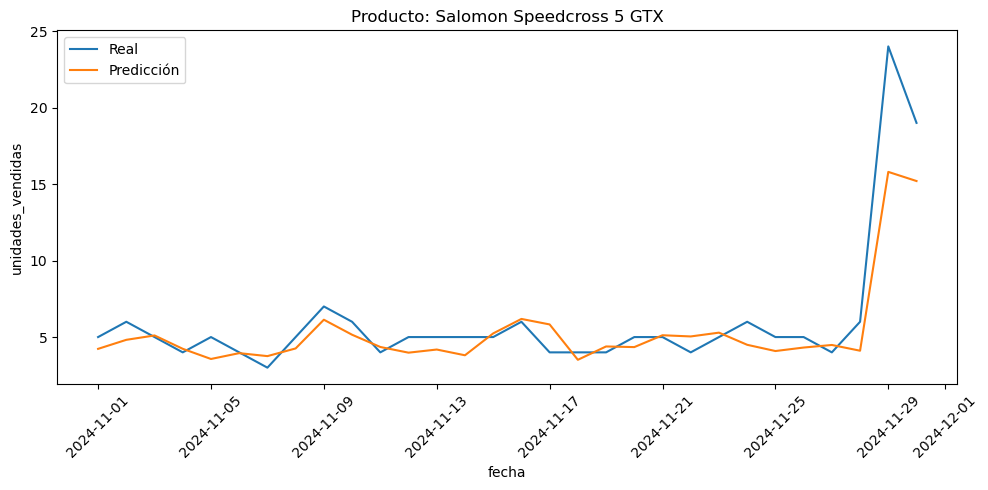

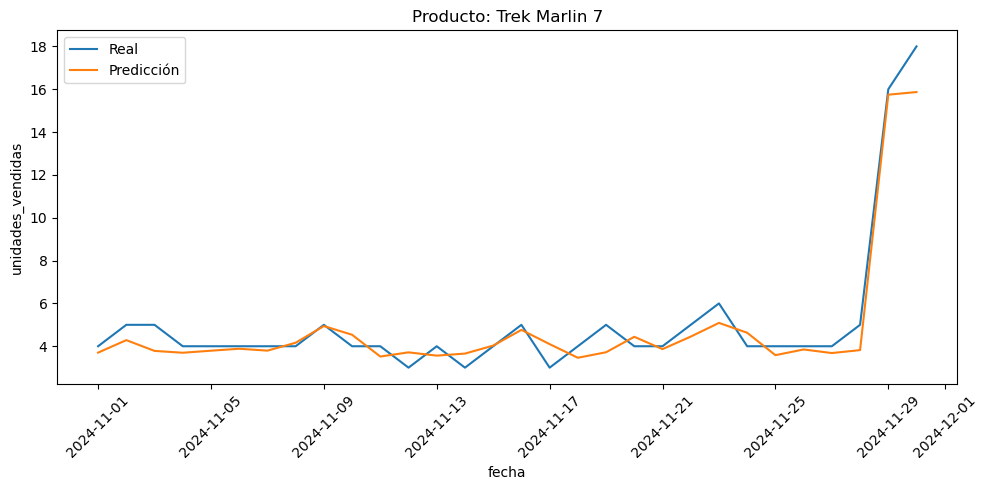

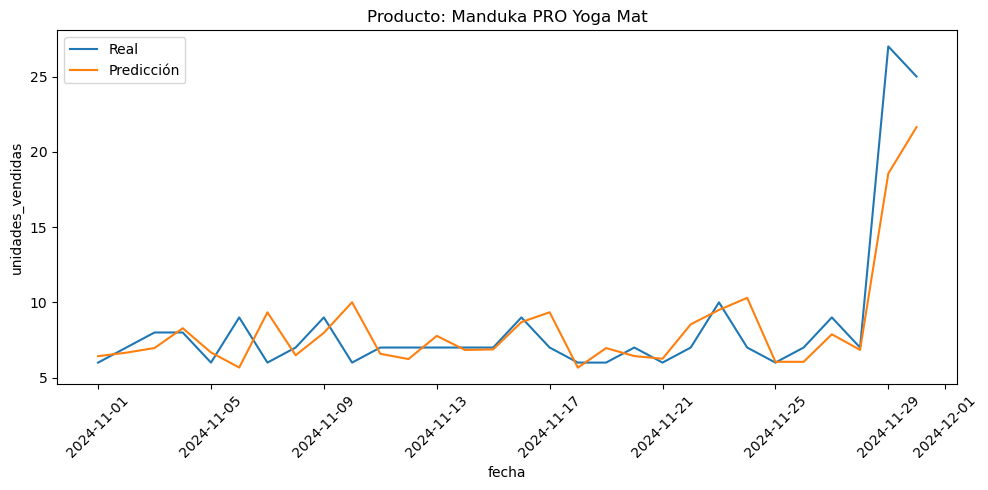

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

productos = df_nov_2024['nombre'].unique()

for producto in productos:
    
    df_temp = df_nov_2024[df_nov_2024['nombre'] == producto]
    
    plt.figure(figsize=(10,5))
    
    sns.lineplot(
        data=df_temp,
        x='fecha',
        y='unidades_vendidas',
        label='Real'
    )
    
    sns.lineplot(
        data=df_temp,
        x='fecha',
        y='prediccion',
        label='Predicción'
    )
    
    plt.title(f"Producto: {producto}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.show()

In [99]:
print(df_nov_2024.shape)
print(df_nov_2024['nombre'].nunique())

(210, 91)
7


In [100]:
from sklearn.metrics import mean_absolute_error

# Agrupar por producto y calcular MAE
mae_por_producto = df_nov_2024.groupby('nombre').apply(
    lambda x: mean_absolute_error(x['unidades_vendidas'], x['prediccion'])
).reset_index()

mae_por_producto.columns = ['nombre', 'MAE']

# Ordenar de mejor a peor (menor error = mejor)
mae_por_producto = mae_por_producto.sort_values(by='MAE')

print(mae_por_producto)

                     nombre       MAE
2              Domyos BM900  0.428065
1    Bowflex SelectTech 552  0.465002
6             Trek Marlin 7  0.547024
5  Salomon Speedcross 5 GTX  1.102329
3      Manduka PRO Yoga Mat  1.380375
0      Adidas Ultraboost 23  5.341045
4  Nike Air Zoom Pegasus 40  5.915860


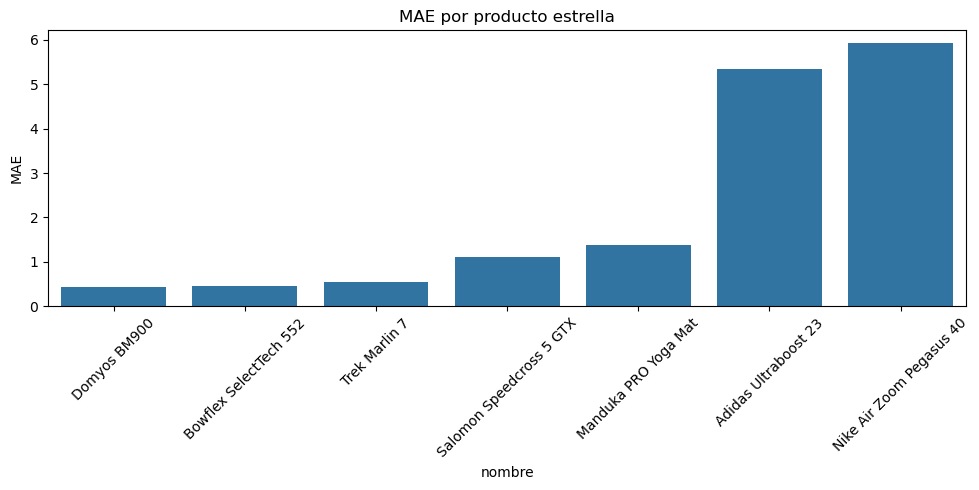

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(data=mae_por_producto, x='nombre', y='MAE')
plt.xticks(rotation=45)
plt.title("MAE por producto estrella")
plt.tight_layout()
plt.show()

In [102]:
# Crear día del mes
df_nov_2024['dia_mes'] = df_nov_2024['fecha'].dt.day

# Crear período
def asignar_periodo(dia):
    if dia <= 10:
        return '1-10'
    elif dia <= 20:
        return '11-20'
    else:
        return '21-30'

df_nov_2024['periodo'] = df_nov_2024['dia_mes'].apply(asignar_periodo)

In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

resultados = []

for periodo in df_nov_2024['periodo'].unique():
    
    temp = df_nov_2024[df_nov_2024['periodo'] == periodo]
    
    mae = mean_absolute_error(temp['unidades_vendidas'], temp['prediccion'])
    rmse = np.sqrt(mean_squared_error(temp['unidades_vendidas'], temp['prediccion']))
    mape = np.mean(np.abs((temp['unidades_vendidas'] - temp['prediccion']) / temp['unidades_vendidas'])) * 100
    
    resultados.append([periodo, mae, rmse, mape])

metricas_periodo = pd.DataFrame(resultados, columns=['periodo', 'MAE', 'RMSE', 'MAPE'])

# Ordenar correctamente
metricas_periodo = metricas_periodo.sort_values(by='periodo')

print(metricas_periodo)

  periodo       MAE      RMSE       MAPE
0    1-10  1.917265  3.081611  19.717859
1   11-20  2.166045  4.081242  22.639226
2   21-30  2.422275  4.281653  17.278737


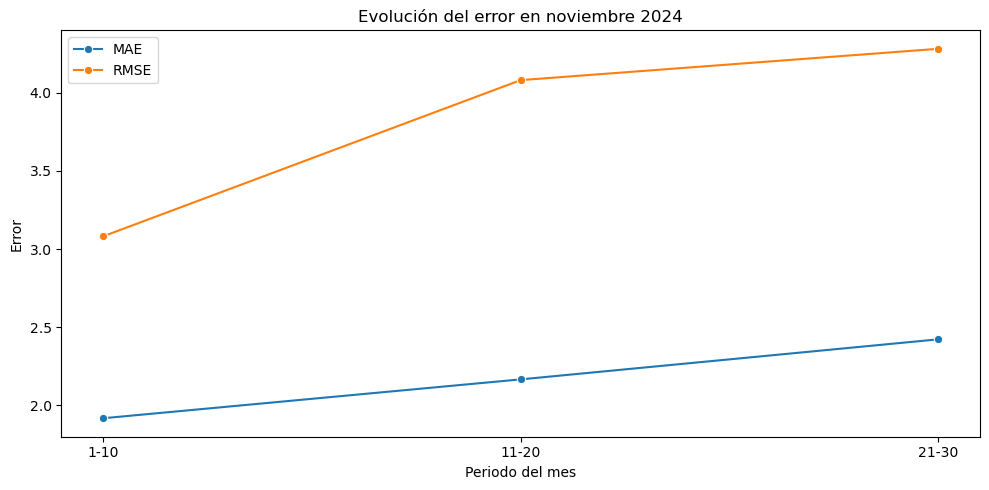

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.lineplot(data=metricas_periodo, x='periodo', y='MAE', marker='o', label='MAE')
sns.lineplot(data=metricas_periodo, x='periodo', y='RMSE', marker='o', label='RMSE')

plt.title("Evolución del error en noviembre 2024")
plt.xlabel("Periodo del mes")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

In [105]:
df_bf_2024 = df[
    (df['fecha'].dt.year == 2024) &
    (df['es_black_friday'] == 1)
]

In [106]:
df_bf_2024['prediccion'] = modelo.predict(df_bf_2024[features])

In [107]:
df_plot = df_bf_2024.groupby('producto_id').agg({
    'unidades_vendidas': 'sum',
    'prediccion': 'sum'
}).reset_index()

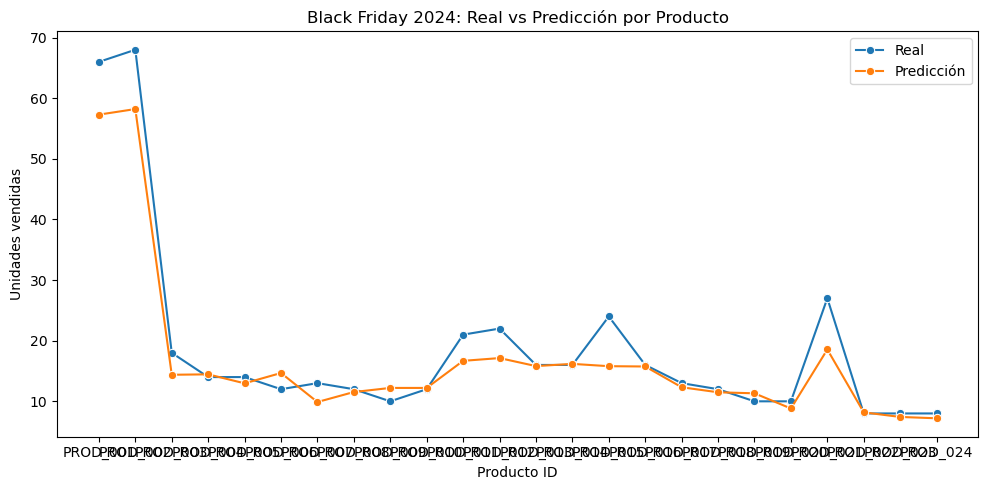

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_plot,
    x='producto_id',
    y='unidades_vendidas',
    marker='o',
    label='Real'
)

sns.lineplot(
    data=df_plot,
    x='producto_id',
    y='prediccion',
    marker='o',
    label='Predicción'
)

plt.title("Black Friday 2024: Real vs Predicción por Producto")
plt.xlabel("Producto ID")
plt.ylabel("Unidades vendidas")
plt.tight_layout()
plt.show()

In [109]:
# Asegurar tipo datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# Filtrar años 2021–2024 (por seguridad)
df_full = df[(df['fecha'].dt.year >= 2021) & (df['fecha'].dt.year <= 2024)]

In [117]:
target = 'unidades_vendidas'

columnas_excluir = ['fecha', 'ingresos']
columnas_objeto = df_full.select_dtypes(include=['object']).columns.tolist()

features = [col for col in df_full.columns 
            if col not in columnas_excluir + columnas_objeto + [target]]

# 🔥 GUARDAR FEATURES (AQUÍ VA)
import joblib

joblib.dump(features, "../features.pkl")

C:\Users\ojgue\AppData\Local\Temp\ipykernel_73740\566096431.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_objeto = df_full.select_dtypes(include=['object']).columns.tolist()


['../features.pkl']

In [118]:
import os

print(os.listdir(".."))

['.github', '.gitignore', 'app', 'app.py', 'data', 'docs', 'features.pkl', 'models', 'notebooks', 'requirements.txt']


In [119]:
print(len(features))
print(features[:10])

82
['precio_base', 'es_estrella', 'precio_venta', 'Amazon_x', 'Decathlon_x', 'Deporvillage_x', 'anio', 'dia_semana', 'es_black_friday', 'mes']


In [121]:
from sklearn.ensemble import HistGradientBoostingRegressor

modelo_final = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_depth=6,
    l2_regularization=1.0,
    random_state=42
)

modelo_final.fit(df_full[features], df_full[target])

,loss,'squared_error'
,quantile,None
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,6
,min_samples_leaf,20
,l2_regularization,1.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [112]:
print("Modelo final entrenado con:", len(df_full), "registros")
print("Número de variables usadas:", len(features))

Modelo final entrenado con: 2880 registros
Número de variables usadas: 82


In [113]:
import pickle

with open("../models/modelo_final.pkl", "wb") as f:
    pickle.dump(modelo_final, f)

In [114]:
from sklearn.inspection import permutation_importance

# Calcular importancia
resultado = permutation_importance(
    modelo_final,
    df_full[features],
    df_full['unidades_vendidas'],
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Crear DataFrame
importancias = pd.DataFrame({
    'feature': features,
    'importance': resultado.importances_mean
})

# Ordenar de mayor a menor
importancias = importancias.sort_values(by='importance', ascending=False)

print(importancias.head(10))

            feature  importance
30    descuento_pct    0.425513
22            lag_1    0.180737
28            lag_7    0.158398
29    media_movil_7    0.063320
7        dia_semana    0.017675
27            lag_6    0.015702
8   es_black_friday    0.010423
5    Deporvillage_x    0.007762
23            lag_2    0.004873
24            lag_3    0.004097


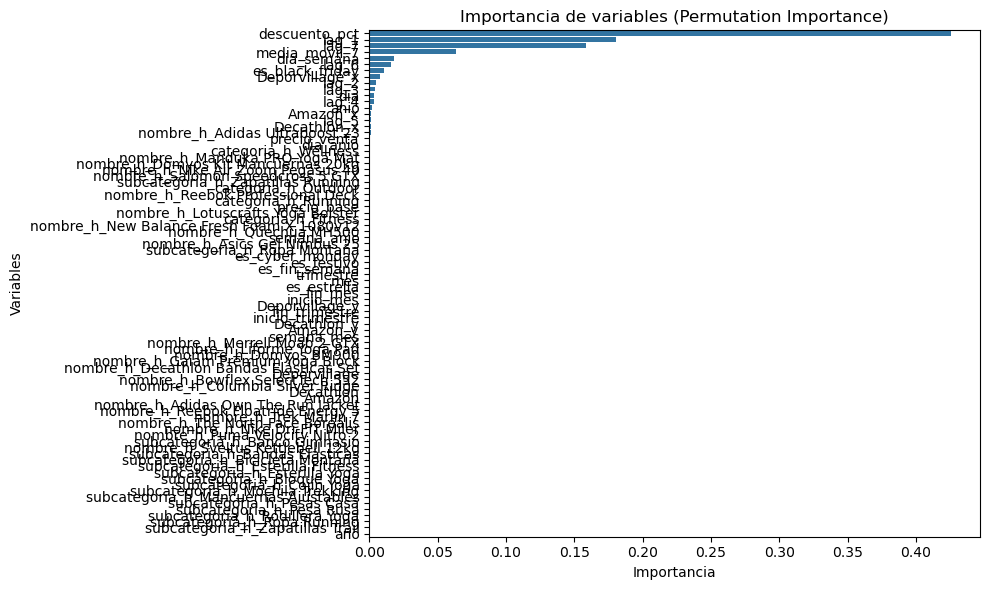

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias,
    y='feature',
    x='importance'
)

plt.title("Importancia de variables (Permutation Importance)")
plt.xlabel("Importancia")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

In [125]:
# 1. Identificar columnas de producto
prod_cols = [c for c in df.columns if 'nombre_' in c]

# 2. Convertir contenido a numérico (Si es texto lo ignora, si es 1/0 lo deja)
for col in prod_cols:
    # Esto convierte cualquier cosa que no sea número a NaN y luego a 0
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

print(f"✅ Se han convertido {len(prod_cols)} columnas a formato numérico.")

# 3. Verificar si ahora hay datos reales (debería salir un número > 0)
total_registros = df[prod_cols].sum().sum()
print(f"Total de registros con '1' ahora: {total_registros}")

# 4. EXPORTAR EL ARCHIVO CORRECTO PARA LA APP
# Asegúrate de que esta ruta sea la que usa tu app.py
df.to_csv('../data/processed/inferencia_df_transformado.csv', index=False)
print("🚀 Archivo exportado correctamente. ¡Reinicia tu App de Streamlit!")

✅ Se han convertido 25 columnas a formato numérico.
Total de registros con '1' ahora: 2880
🚀 Archivo exportado correctamente. ¡Reinicia tu App de Streamlit!
